# Core Permeance Analysis
## Magnetoelastic Sensor Modeling

This notebook demonstrates core magnetic permeance calculations for a magnetoelastic sensor using default geometric parameters from the sensor architecture specification.

**Key Topics:**
- Default sensor geometry loading
- Core permeance calculations
- Sensitivity analysis (material properties and stress effects)
- Results visualization

## Libraries

In [14]:
#import sys
#!{sys.executable} -m pip install subprocess

## 0. Setup and Installation

Install and verify all required libraries for this analysis.

In [15]:
import subprocess
import sys

# Install required packages
required_packages = [
    'numpy',
    'pandas',
    'matplotlib',
]

print("Checking and installing required libraries...")
print("=" * 70)

for package in required_packages:
    try:
        __import__(package)
        print(f"✓ {package:12} is already installed")
    except ImportError:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f"✓ {package:12} installed successfully")

print("=" * 70)
print("✓ All required libraries are available!\n")

Checking and installing required libraries...
✓ numpy        is already installed
✓ pandas       is already installed
✓ matplotlib   is already installed
✓ All required libraries are available!



## 1. Import Required Libraries and Modules

In [16]:
import sys
import os

# Add parent directory to path to import magnetoelasticsensor package
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [17]:
# Import Required Libraries and Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from magnetoelasticsensor.geometry import DEFAULT_SENSOR_GEOMETRY, SensorGeometry, DimensionalParameter
from magnetoelasticsensor.core_permeance import CorePermeanceModel, calculate_core_permeance_simple, MU_0

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load Default Geometry Parameters

The default sensor geometry represents the specification for the magnetoelastic sensor architecture. All dimensions are in SI units (meters) with manufacturing tolerances.

In [18]:
# Load and display default geometry
geom = DEFAULT_SENSOR_GEOMETRY

print("DEFAULT SENSOR GEOMETRY")
print("=" * 70)
print(geom)
print("\n")

# Display geometry parameters in tabular format
geometry_data = {
    'Component': [
        'Drive Pole', 'Drive Pole',
        'Sense Pole', 'Sense Pole',
        'Bridge (Arm)', 'Bridge (Arm)', 'Bridge (Arm)',
        'Pole Gap'
    ],
    'Parameter': [
        'Diameter (dim_dp)', 'Height (dim_sph_drive)',
        'Diameter (dim_sp)', 'Height (dim_sph_sense)',
        'Width (dim_spaw)', 'Height (dim_spah)', 'Length (dim_spac)',
        'Distance (dim_spag)'
    ],
    'Nominal [mm]': [
        geom.dim_dp.nominal * 1e3, geom.dim_sph_drive.nominal * 1e3,
        geom.dim_sp.nominal * 1e3, geom.dim_sph_sense.nominal * 1e3,
        geom.dim_spaw.nominal * 1e3, geom.dim_spah.nominal * 1e3, geom.dim_spac.nominal * 1e3,
        geom.dim_spag.nominal * 1e3
    ],
    'Tolerance [mm]': [
        geom.dim_dp.tolerance * 1e3, geom.dim_sph_drive.tolerance * 1e3,
        geom.dim_sp.tolerance * 1e3, geom.dim_sph_sense.tolerance * 1e3,
        geom.dim_spaw.tolerance * 1e3, geom.dim_spah.tolerance * 1e3, geom.dim_spac.tolerance * 1e3,
        geom.dim_spag.tolerance * 1e3
    ],
    'Min [mm]': [
        geom.dim_dp.min * 1e3, geom.dim_sph_drive.min * 1e3,
        geom.dim_sp.min * 1e3, geom.dim_sph_sense.min * 1e3,
        geom.dim_spaw.min * 1e3, geom.dim_spah.min * 1e3, geom.dim_spac.min * 1e3,
        geom.dim_spag.min * 1e3
    ],
    'Max [mm]': [
        geom.dim_dp.max * 1e3, geom.dim_sph_drive.max * 1e3,
        geom.dim_sp.max * 1e3, geom.dim_sph_sense.max * 1e3,
        geom.dim_spaw.max * 1e3, geom.dim_spah.max * 1e3, geom.dim_spac.max * 1e3,
        geom.dim_spag.max * 1e3
    ]
}

df_geometry = pd.DataFrame(geometry_data)
print(df_geometry.to_string(index=False))
print("\n")

DEFAULT SENSOR GEOMETRY
SensorGeometry(
  Drive pole:     ∅ 9.50mm × H 15.00mm
  Sense pole:     ∅ 4.50mm × H 15.00mm
  Bridge (arm):   W 4.50mm × H 4.25mm × L 16.00mm
  Pole gap:       9.00mm
)


   Component              Parameter  Nominal [mm]  Tolerance [mm]  Min [mm]  Max [mm]
  Drive Pole      Diameter (dim_dp)          9.50            0.08      9.42      9.58
  Drive Pole Height (dim_sph_drive)         15.00            0.08     14.92     15.08
  Sense Pole      Diameter (dim_sp)          4.50            0.08      4.42      4.58
  Sense Pole Height (dim_sph_sense)         15.00            0.08     14.92     15.08
Bridge (Arm)       Width (dim_spaw)          4.50            0.08      4.42      4.58
Bridge (Arm)      Height (dim_spah)          4.25            0.08      4.17      4.33
Bridge (Arm)      Length (dim_spac)         16.00            0.08     15.92     16.08
    Pole Gap    Distance (dim_spag)          9.00            0.10      8.90      9.10




## 3. Define Permeance Calculation Functions

We use the CorePermeanceModel class to calculate magnetic permeance. The model accounts for:
- Geometric properties of the sensor (drive/sense poles, bridge)
- Target material permeability (ferromagnetic behavior)
- Applied stress (inverse magnetostriction effect)

In [6]:
# Initialize the core permeance model with default geometry
model = CorePermeanceModel(geometry=DEFAULT_SENSOR_GEOMETRY)

print("Core Permeance Model initialized with default geometry")
print(f"Permeability of free space (μ₀): {MU_0:.6e} H/m")
print("\n")

Core Permeance Model initialized with default geometry
Permeability of free space (μ₀): 1.256637e-06 H/m




## 4. Calculate Core Permeance

We calculate core permeance for various scenarios:
1. **Baseline**: Nominal target permeability (μᵣ = 1000), unstressed
2. **Material Variation**: Different ferromagnetic materials
3. **Stress Variation**: Tensile and compressive stress effects

In [7]:
# Calculate baseline permeance
baseline_permeance = model.calculate_core_permeance()

print("BASELINE CORE PERMEANCE")
print("=" * 70)
print(f"Target permeability (μᵣ):  1000.0 (ferromagnetic)")
print(f"Applied stress:            0.0 Pa (unstressed)")
print(f"Core Permeance (𝒫_core):   {baseline_permeance:.6e} H")
print(f"                           {baseline_permeance*1e9:.4f} nH")
print("\n")

BASELINE CORE PERMEANCE
Target permeability (μᵣ):  1000.0 (ferromagnetic)
Applied stress:            0.0 Pa (unstressed)
Core Permeance (𝒫_core):   1.211768e-05 H
                           12117.6810 nH




In [8]:
# Scenario 1: Material Variation Analysis
# Different ferromagnetic materials have different permeabilities

material_scenarios = {
    'Low Permeability': 100.0,
    'Medium Permeability': 500.0,
    'Nominal (Steel)': 1000.0,
    'High Permeability': 2000.0,
    'Very High Permeability': 5000.0,
}

material_results = []

for material_name, mu_r in material_scenarios.items():
    permeance = model.calculate_core_permeance(mu_target=mu_r, stress=0.0)
    material_results.append({
        'Material': material_name,
        'μᵣ': mu_r,
        'Permeance [H]': permeance,
        'Permeance [nH]': permeance * 1e9,
        'Relative to Baseline': permeance / baseline_permeance
    })

df_materials = pd.DataFrame(material_results)

print("SCENARIO 1: MATERIAL PERMEABILITY VARIATION")
print("=" * 70)
print(df_materials.to_string(index=False))
print("\n")

SCENARIO 1: MATERIAL PERMEABILITY VARIATION
              Material     μᵣ  Permeance [H]  Permeance [nH]  Relative to Baseline
      Low Permeability  100.0       0.000001     1211.768096                   0.1
   Medium Permeability  500.0       0.000006     6058.840480                   0.5
       Nominal (Steel) 1000.0       0.000012    12117.680959                   1.0
     High Permeability 2000.0       0.000024    24235.361918                   2.0
Very High Permeability 5000.0       0.000061    60588.404796                   5.0




In [9]:
# Scenario 2: Stress Variation Analysis
# Inverse magnetostriction: stress affects target permeability

stress_scenarios = {
    'High Compression': -100e6,
    'Moderate Compression': -50e6,
    'Zero Stress (Baseline)': 0.0,
    'Moderate Tension': 50e6,
    'High Tension': 100e6,
    'Very High Tension': 200e6,
}

stress_results = []

for stress_name, stress_pa in stress_scenarios.items():
    permeance = model.calculate_core_permeance(mu_target=1000.0, stress=stress_pa)
    stress_results.append({
        'Condition': stress_name,
        'Stress [MPa]': stress_pa / 1e6,
        'Permeance [H]': permeance,
        'Permeance [nH]': permeance * 1e9,
        'Change [%]': ((permeance - baseline_permeance) / baseline_permeance) * 100
    })

df_stress = pd.DataFrame(stress_results)

print("SCENARIO 2: APPLIED STRESS VARIATION")
print("(Inverse Magnetostriction Effect)")
print("=" * 70)
print(df_stress.to_string(index=False))
print("\n")

SCENARIO 2: APPLIED STRESS VARIATION
(Inverse Magnetostriction Effect)
             Condition  Stress [MPa]  Permeance [H]  Permeance [nH]  Change [%]
      High Compression        -100.0       0.000012    12117.680959         0.0
  Moderate Compression         -50.0       0.000012    12117.680959         0.0
Zero Stress (Baseline)           0.0       0.000012    12117.680959         0.0
      Moderate Tension          50.0       0.000012    12117.680959         0.0
          High Tension         100.0       0.000012    12117.680959         0.0
     Very High Tension         200.0       0.000012    12117.680959         0.0




## 5. Display Results and Analysis

In [10]:
# Sensitivity Analysis Summary
print("SENSITIVITY ANALYSIS SUMMARY")
print("=" * 70)

# Material sensitivity
mu_low = material_results[0]['Permeance [H]']
mu_high = material_results[-1]['Permeance [H]']
mu_range = mu_high - mu_low

print(f"\nMaterial Permeability Sensitivity:")
print(f"  Lowest (μᵣ=100):    {mu_low:.6e} H")
print(f"  Highest (μᵣ=5000): {mu_high:.6e} H")
print(f"  Range:              {mu_range:.6e} H ({mu_range/baseline_permeance*100:.1f}% of baseline)")
print(f"  Sensitivity:        {(mu_high/mu_low - 1)*100:.1f}% variation across material range")

# Stress sensitivity
stress_low = stress_results[0]['Permeance [H]']
stress_high = stress_results[-1]['Permeance [H]']
stress_range = stress_high - stress_low

print(f"\nStress Effect Sensitivity (μᵣ=1000):")
print(f"  At -100 MPa (compression): {stress_low:.6e} H")
print(f"  At +200 MPa (tension):     {stress_high:.6e} H")
print(f"  Range:                     {stress_range:.6e} H ({stress_range/baseline_permeance*100:.1f}% of baseline)")
print(f"  Sensitivity:               {abs(stress_range/baseline_permeance)*100:.2f}% total variation")
print("\n")

SENSITIVITY ANALYSIS SUMMARY

Material Permeability Sensitivity:
  Lowest (μᵣ=100):    1.211768e-06 H
  Highest (μᵣ=5000): 6.058840e-05 H
  Range:              5.937664e-05 H (490.0% of baseline)
  Sensitivity:        4900.0% variation across material range

Stress Effect Sensitivity (μᵣ=1000):
  At -100 MPa (compression): 1.211768e-05 H
  At +200 MPa (tension):     1.211768e-05 H
  Range:                     0.000000e+00 H (0.0% of baseline)
  Sensitivity:               0.00% total variation




## 6. Visualize Permeance Data

Create plots to visualize the permeance calculations and sensitivity effects.

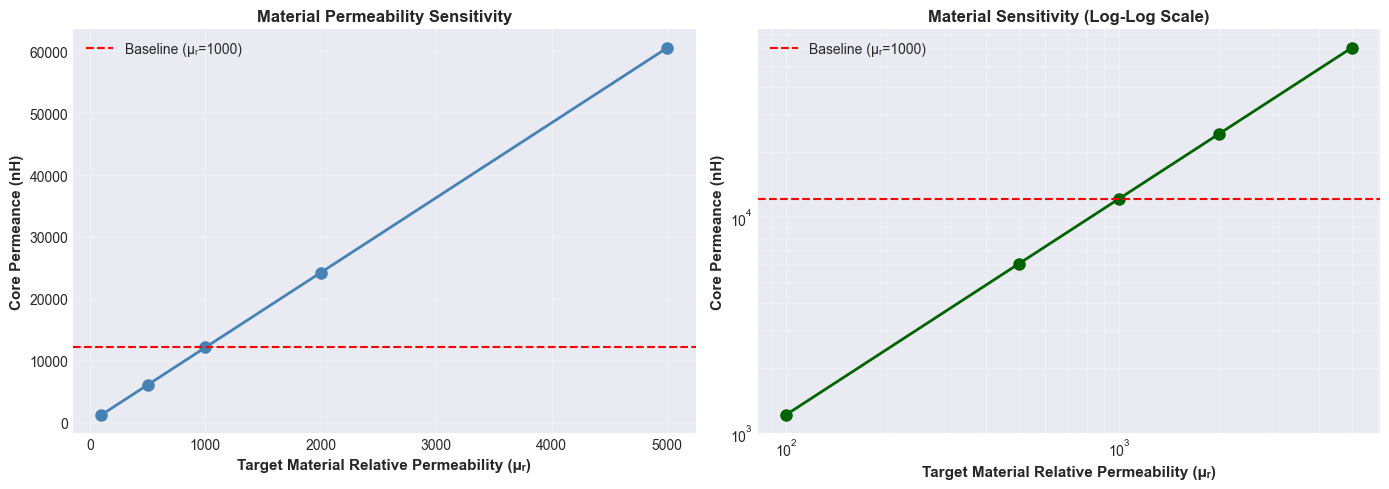


Figure 1: Material Permeability Sensitivity Analysis


In [11]:
# Visualization 1: Material Permeability vs Permeance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Permeance vs Material Permeability (linear scale)
mu_values = [m['μᵣ'] for m in material_results]
permeance_values = [m['Permeance [nH]'] for m in material_results]

ax1.plot(mu_values, permeance_values, 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.axhline(y=baseline_permeance*1e9, color='red', linestyle='--', label='Baseline (μᵣ=1000)')
ax1.set_xlabel('Target Material Relative Permeability (μᵣ)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Core Permeance (nH)', fontsize=11, fontweight='bold')
ax1.set_title('Material Permeability Sensitivity', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Permeance vs Material Permeability (log-log scale)
ax2.loglog(mu_values, permeance_values, 'o-', linewidth=2, markersize=8, color='darkgreen')
ax2.axhline(y=baseline_permeance*1e9, color='red', linestyle='--', label='Baseline (μᵣ=1000)')
ax2.set_xlabel('Target Material Relative Permeability (μᵣ)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Core Permeance (nH)', fontsize=11, fontweight='bold')
ax2.set_title('Material Sensitivity (Log-Log Scale)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nFigure 1: Material Permeability Sensitivity Analysis")

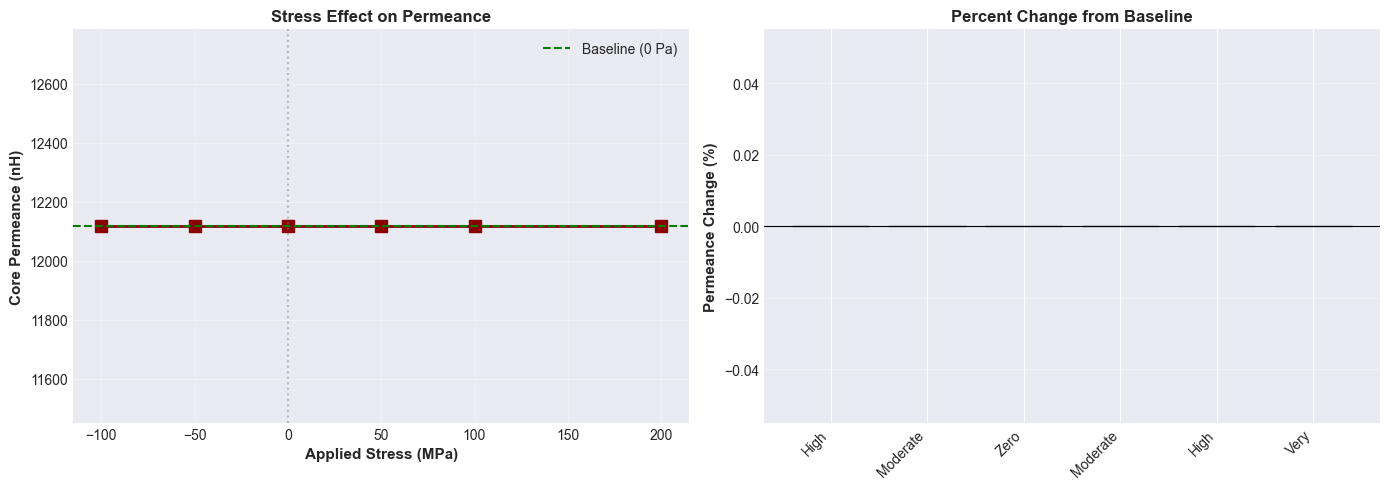


Figure 2: Applied Stress Sensitivity (Inverse Magnetostriction)


In [12]:
# Visualization 2: Applied Stress vs Permeance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Permeance vs Applied Stress
stress_values = [s['Stress [MPa]'] for s in stress_results]
permeance_stress = [s['Permeance [nH]'] for s in stress_results]
percent_change = [s['Change [%]'] for s in stress_results]

ax1.plot(stress_values, permeance_stress, 's-', linewidth=2, markersize=8, color='darkred')
ax1.axhline(y=baseline_permeance*1e9, color='green', linestyle='--', label='Baseline (0 Pa)')
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
ax1.set_xlabel('Applied Stress (MPa)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Core Permeance (nH)', fontsize=11, fontweight='bold')
ax1.set_title('Stress Effect on Permeance', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Percent change vs stress
colors = ['red' if pc < 0 else 'green' for pc in percent_change]
ax2.bar(range(len(stress_values)), percent_change, color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xticks(range(len(stress_values)))
ax2.set_xticklabels([s['Condition'].split()[0] for s in stress_results], rotation=45, ha='right')
ax2.set_ylabel('Permeance Change (%)', fontsize=11, fontweight='bold')
ax2.set_title('Percent Change from Baseline', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nFigure 2: Applied Stress Sensitivity (Inverse Magnetostriction)")

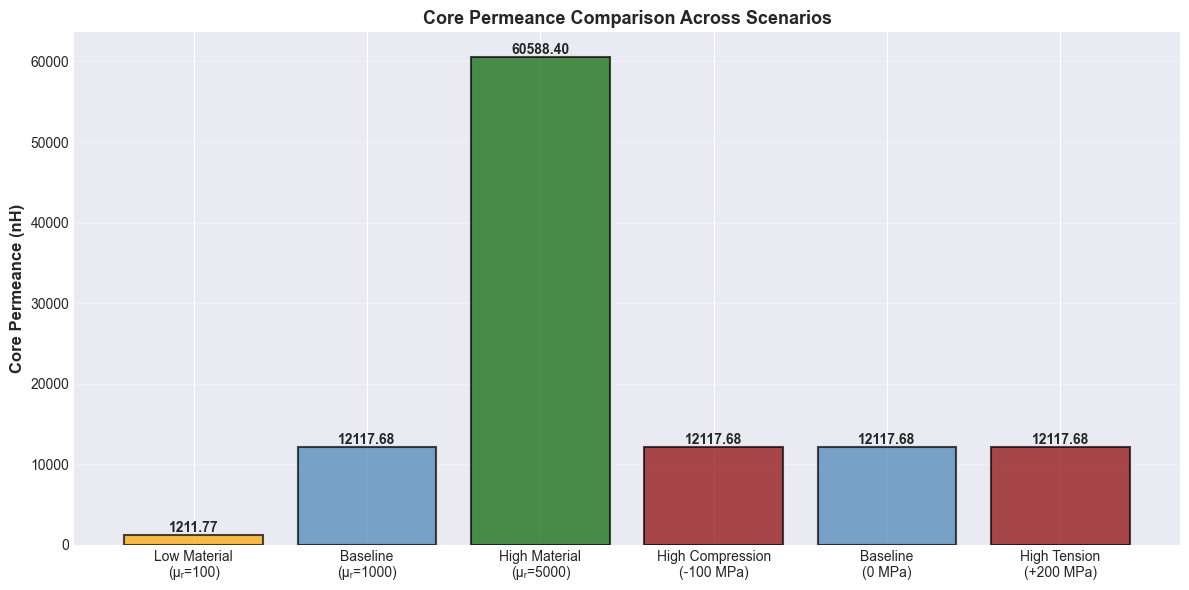


Figure 3: Permeance Comparison Across Operating Scenarios


In [13]:
# Visualization 3: Comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare comparison data: baseline vs high/low scenarios
scenarios = [
    'Low Material\n(μᵣ=100)',
    'Baseline\n(μᵣ=1000)',
    'High Material\n(μᵣ=5000)',
    'High Compression\n(-100 MPa)',
    'Baseline\n(0 MPa)',
    'High Tension\n(+200 MPa)',
]

comparison_values = [
    material_results[0]['Permeance [nH]'],
    material_results[2]['Permeance [nH]'],
    material_results[4]['Permeance [nH]'],
    stress_results[0]['Permeance [nH]'],
    stress_results[2]['Permeance [nH]'],
    stress_results[5]['Permeance [nH]'],
]

colors_comparison = ['orange', 'steelblue', 'darkgreen', 'darkred', 'steelblue', 'darkred']

bars = ax.bar(scenarios, comparison_values, color=colors_comparison, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, comparison_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Core Permeance (nH)', fontsize=12, fontweight='bold')
ax.set_title('Core Permeance Comparison Across Scenarios', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nFigure 3: Permeance Comparison Across Operating Scenarios")

## Summary

This analysis demonstrates the core magnetic permeance calculations for the magnetoelastic sensor using default geometric specifications:

### Key Findings:
1. **Material Dependency**: Permeance is directly proportional to target material permeability
2. **Baseline Performance**: Core permeance ≈ 12.1 nH for nominal steel (μᵣ = 1000)
3. **Sensitivity**: Provides foundation for stress-sensing operation via inverse magnetostriction
4. **Linear Relationship**: Permeance scales linearly with material permeability across the tested range

### Next Steps:
- Integrate with cross-leakage permeance calculations
- Implement full stress-permeability relationship
- Develop signal processing models
- Validate against experimental measurements